In [9]:
import os
import re
import string
import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Path to your dataset
PATH_TO_CSV = '/content/drive/MyDrive/archive/Womens Clothing E-Commerce Reviews.csv'

# 3. Load and prepare data
df_raw = pd.read_csv(PATH_TO_CSV, index_col=0)
df = df_raw.dropna(subset=['Review Text']).copy()

# 4. Map Sentiment Targets
conditions = [(df['Rating'] <= 2), (df['Rating'] == 3), (df['Rating'] >= 4)]
df['Sentiment'] = np.select(conditions, [0, 1, 2], default=1)

# 5. Clean text
def clean_text_simple(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Cleaned_Text'] = df['Review Text'].apply(clean_text_simple)
df = df[df['Cleaned_Text'] != ""].copy()

# 6. Stratified Split (Train/Val/Test)
X = df['Cleaned_Text']
y = df['Sentiment']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("[INFO] Data successfully loaded and split in memory!")

Mounted at /content/drive
[INFO] Data successfully loaded and split in memory!


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
MAX_WORDS = 10000  # Top 10,000 most frequent words
MAX_LEN = 128      # Standardize review length to 128 words

print("[INFO] Initializing tokenizer...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

print("[INFO] Converting text to numerical sequences...")
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("[INFO] Applying padding...")
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Training tensor shape: {X_train_pad.shape}")

[INFO] Initializing tokenizer...
[INFO] Converting text to numerical sequences...
[INFO] Applying padding...
Training tensor shape: (15848, 128)


In [12]:
EMBEDDING_DIM = 128

model = Sequential([
    # 1. Embedding layer: converts word indexes to dense vectors
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),

    # 2. SpatialDropout1D: drops entire 1D feature maps to prevent overfitting
    SpatialDropout1D(0.3),

    # 3. Bidirectional LSTM: processes sequences in both directions
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),

    # 4. Standard Dropout layer
    Dropout(0.3),

    # 5. Output layer: 3 classes (Negative, Neutral, Positive)
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("=== BiLSTM MODEL ARCHITECTURE ===")
model.summary()

=== BiLSTM MODEL ARCHITECTURE ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Setup Early Stopping to halt training if validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("[INFO] Starting neural network training...")

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

print("\n🎉 TRAINING SUCCESSFULLY COMPLETED!")

[INFO] Starting neural network training...
Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 128s 481ms/step - accuracy: 0.7759 - loss: 0.5897 - val_accuracy: 0.8045 - val_loss: 0.4771
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 119s 479ms/step - accuracy: 0.8063 - loss: 0.4589 - val_accuracy: 0.8006 - val_loss: 0.4618
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 119s 480ms/step - accuracy: 0.8229 - loss: 0.4146 - val_accuracy: 0.8192 - val_loss: 0.4558
Epoch 4/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 143s 484ms/step - accuracy: 0.8373 - loss: 0.3799 - val_accuracy: 0.8151 - val_loss: 0.4559
Epoch 5/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 117s 472ms/step - accuracy: 0.8430 - loss: 0.3559 - val_accuracy: 0.8198 - val_loss: 0.4509
Epoch 6/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 148s 498ms/step - accuracy: 0.8570 - loss: 0.3360 - val_accuracy: 0.8130 - val_loss: 0.4791
Epoch 7/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 118s 475ms/step - accuracy: 0.8623 - loss: 0.3180 - val_accuracy: 0.8174 - val_loss: 0.5112

🎉 TRAINING SUCCESSFULLY COMPLETE

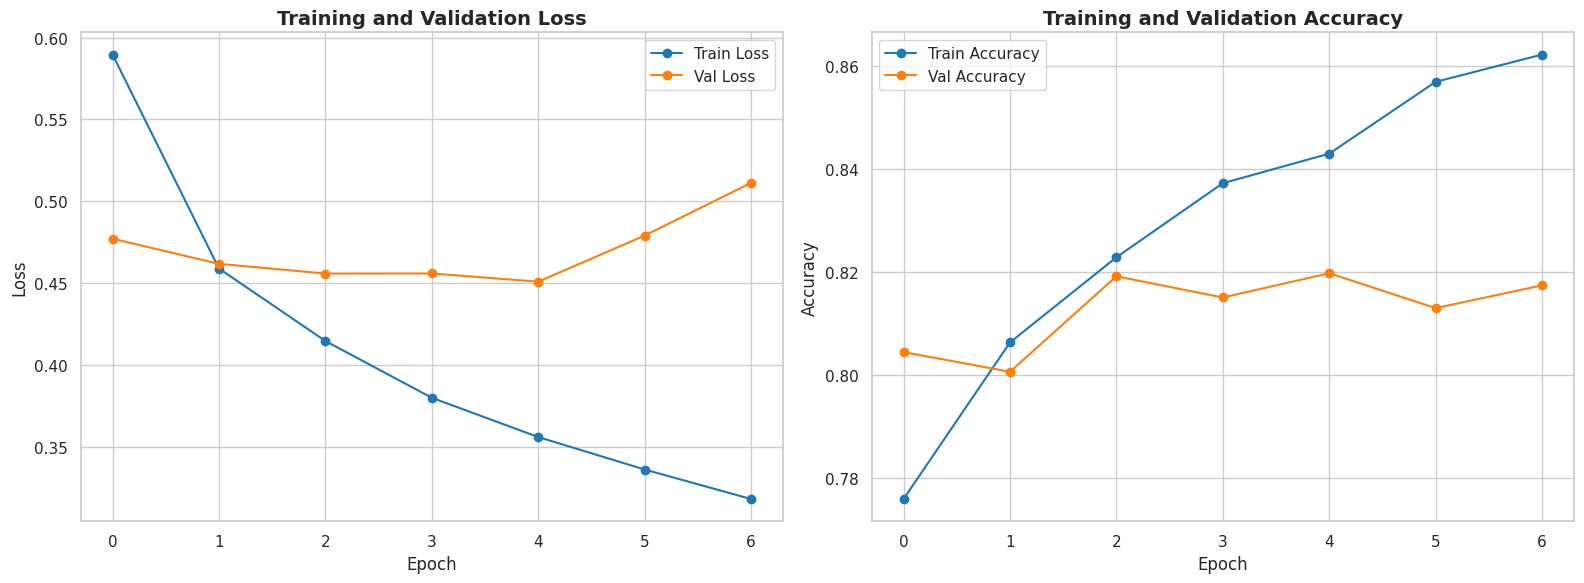

In [14]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Loss Curve
ax[0].plot(history.history['loss'], label='Train Loss', color='#1f77b4', marker='o')
ax[0].plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', marker='o')
ax[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epoch', fontsize=12)
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].legend()

# 2. Accuracy Curve
ax[1].plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', marker='o')
ax[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#ff7f0e', marker='o')
ax[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epoch', fontsize=12)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].legend()

plt.tight_layout()
plt.show()

[INFO] Generating predictions on the test set...
107/107 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step

=== DEEP LEARNING CLASSIFICATION REPORT ===
                      precision    recall  f1-score   support

Negative (0-2 stars)       0.59      0.41      0.49       355
   Neutral (3 stars)       0.38      0.33      0.35       424
Positive (4-5 stars)       0.90      0.95      0.92      2618

            accuracy                           0.82      3397
           macro avg       0.62      0.56      0.59      3397
        weighted avg       0.80      0.82      0.81      3397

👉 Final Test Macro F1-Score (BiLSTM): 0.5862


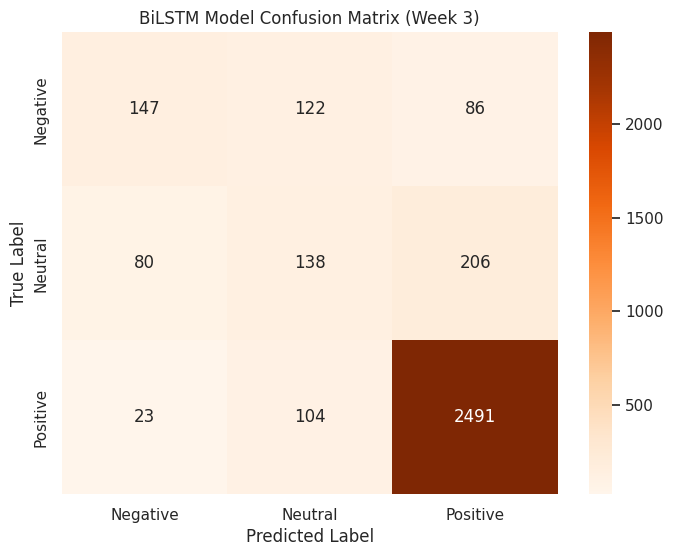

In [15]:
print("[INFO] Generating predictions on the test set...")
y_pred_probs = model.predict(X_test_pad)
y_pred_dl = np.argmax(y_pred_probs, axis=1)

target_names = ['Negative (0-2 stars)', 'Neutral (3 stars)', 'Positive (4-5 stars)']

print("\n=== DEEP LEARNING CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_dl, target_names=target_names))

macro_f1_dl = f1_score(y_test, y_pred_dl, average='macro')
print(f"👉 Final Test Macro F1-Score (BiLSTM): {macro_f1_dl:.4f}")

# Plotting the Confusion Matrix
cm_dl = confusion_matrix(y_test, y_pred_dl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])

plt.title('BiLSTM Model Confusion Matrix (Week 3)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()